# Feature Importance & Correlation Analysis

**Goal**: Understand which features drive the 3 target variables (Total Alkalinity, EC, DRP) for both feature selection and domain understanding.

**Approach**:
1. Load & prep — identify feature groups, handle dtypes
2. Correlation matrix (Pearson + Spearman) per target
3. Random Forest feature importance per target
4. Summary: top features per target, feature group contributions

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# ============================================================
# CONFIGURE THIS PATH
# ============================================================
DATA_PATH = 'data/dws_matched_all_columns.csv'  # <-- your merged file

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {len(df.columns)}')

Shape: (9319, 69)
Columns: 69


## 1. Define Targets & Feature Groups

In [2]:
# Target columns
TARGETS = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

# Columns to EXCLUDE from features (metadata, IDs, merge flags, geometry, targets themselves)
EXCLUDE = [
    # Targets
    'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus',
    # IDs & metadata
    'Sample Date', 'geometry', 'STAT_ID', 'Impute_Method',
    '_merge_terra', '_merge_landsat',
    'dws_station_id', 'dws_date', 'dws_Station',
    'date',
    # Coordinates used for matching (not true features)
    'Latitude_glorich', 'Longitude_glorich',
]

# Get all numeric columns that aren't excluded
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in EXCLUDE]
print(f'Total numeric features: {len(feature_cols)}')

# Group features for interpretability
FEATURE_GROUPS = {
    'Location':       ['Latitude', 'Longitude'],
    'Climate':        ['pet'],
    'Landsat':        ['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI'],
    'GLiM (lithology)': ['sc', 'ss', 'su', 'mt', 'va', 'vb', 'vi', 'pa', 'pb', 'pi'],
    'Land cover':     ['GLC_Artificial', 'GLC_Managed', 'GLC_Water', 'GLC_Aquatic_Veg', 'GLC_PERC_COV'],
    'Soil':           ['Soil_pH', 'SOC', 'Soil_wetness'],
    'Population':     ['Popdens_00'],
    'GLORICH':        ['Alkalinity', 'Cl', 'DIP', 'SO4', 'SpecCond25C', 'pH',
                       'Alkalinity_reliability', 'Cl_reliability', 'DIP_reliability',
                       'SO4_reliability', 'SpecCond25C_reliability', 'pH_reliability',
                       'date_diff_days'],
    'DWS':            ['Total Alkalinity (DWS)', 'Electrical Conductance (DWS)',
                       'Dissolved Reactive Phosphorus (DWS)',
                       'dws_pH', 'dws_Ca', 'dws_Mg', 'dws_Na', 'dws_Cl',
                       'dws_SO4', 'dws_P_Tot', 'days_diff'],
    'Distance':       ['dist_m', 'dist_km'],
}

# Verify all feature_cols are assigned to a group
grouped = set()
for cols in FEATURE_GROUPS.values():
    grouped.update(cols)
ungrouped = [c for c in feature_cols if c not in grouped]
if ungrouped:
    print(f'Ungrouped features (will be added to "Other"): {ungrouped}')
    FEATURE_GROUPS['Other'] = ungrouped

# Filter to only features that exist in the dataframe
for grp, cols in FEATURE_GROUPS.items():
    FEATURE_GROUPS[grp] = [c for c in cols if c in feature_cols]

print('\nFeature groups:')
for grp, cols in FEATURE_GROUPS.items():
    print(f'  {grp}: {len(cols)} features')

Total numeric features: 54

Feature groups:
  Location: 2 features
  Climate: 1 features
  Landsat: 6 features
  GLiM (lithology): 10 features
  Land cover: 5 features
  Soil: 3 features
  Population: 1 features
  GLORICH: 13 features
  DWS: 11 features
  Distance: 2 features


In [3]:
# Coverage summary per feature
coverage = pd.DataFrame({
    'feature': feature_cols,
    'non_null': [df[c].notna().sum() for c in feature_cols],
    'pct_coverage': [df[c].notna().mean() * 100 for c in feature_cols],
    'group': [next((g for g, cols in FEATURE_GROUPS.items() if c in cols), 'Unknown') for c in feature_cols]
}).sort_values('pct_coverage')

print('Features with <50% coverage (will still be used, RF handles missingness via imputation):')
low_cov = coverage[coverage['pct_coverage'] < 50]
for _, row in low_cov.iterrows():
    print(f'  {row["feature"]}: {row["pct_coverage"]:.1f}% ({row["group"]})')

Features with <50% coverage (will still be used, RF handles missingness via imputation):
  dws_P_Tot: 7.6% (DWS)
  dws_Na: 29.1% (DWS)
  dws_SO4: 39.0% (DWS)
  Total Alkalinity (DWS): 39.3% (DWS)
  dws_Mg: 39.3% (DWS)
  dws_Ca: 39.6% (DWS)
  dws_Cl: 39.9% (DWS)
  Dissolved Reactive Phosphorus (DWS): 40.2% (DWS)
  Electrical Conductance (DWS): 40.3% (DWS)
  dws_pH: 40.3% (DWS)
  dist_km: 41.2% (Distance)
  days_diff: 41.2% (DWS)


## 2. Correlation Analysis

Pearson (linear) + Spearman (monotonic/rank) correlations of every feature against each target.

In [4]:
# Compute correlations with each target
corr_results = []

for feat in feature_cols:
    for target in TARGETS:
        mask = df[[feat, target]].dropna()
        if len(mask) < 30:  # skip if too few valid pairs
            continue
        
        pearson = mask[feat].corr(mask[target])
        spearman = mask[feat].corr(mask[target], method='spearman')
        group = next((g for g, cols in FEATURE_GROUPS.items() if feat in cols), 'Unknown')
        
        corr_results.append({
            'feature': feat,
            'target': target,
            'pearson': pearson,
            'spearman': spearman,
            'abs_pearson': abs(pearson),
            'abs_spearman': abs(spearman),
            'n_valid': len(mask),
            'group': group,
        })

corr_df = pd.DataFrame(corr_results)
print(f'Computed {len(corr_df)} feature-target correlation pairs')

Computed 162 feature-target correlation pairs


In [5]:
# Top 15 correlations per target (by absolute Spearman — more robust to outliers)
for target in TARGETS:
    print(f'\n{"="*60}')
    print(f'TOP 15 FEATURES correlated with: {target}')
    print(f'{"="*60}')
    
    sub = corr_df[corr_df['target'] == target].sort_values('abs_spearman', ascending=False).head(15)
    for _, row in sub.iterrows():
        direction = '+' if row['spearman'] > 0 else '-'
        print(f"  {direction} {row['feature']:45s} Spearman={row['spearman']:+.3f}  Pearson={row['pearson']:+.3f}  (n={row['n_valid']:,}, {row['group']})")


TOP 15 FEATURES correlated with: Total Alkalinity
  + Alkalinity                                    Spearman=+0.825  Pearson=+0.722  (n=7,719, GLORICH)
  + Total Alkalinity (DWS)                        Spearman=+0.807  Pearson=+0.783  (n=3,663, DWS)
  + dws_Ca                                        Spearman=+0.756  Pearson=+0.626  (n=3,687, DWS)
  + dws_Mg                                        Spearman=+0.726  Pearson=+0.444  (n=3,667, DWS)
  + SpecCond25C                                   Spearman=+0.691  Pearson=+0.485  (n=7,719, GLORICH)
  + SO4                                           Spearman=+0.675  Pearson=+0.396  (n=7,719, GLORICH)
  + Electrical Conductance (DWS)                  Spearman=+0.648  Pearson=+0.329  (n=3,752, DWS)
  + dws_SO4                                       Spearman=+0.634  Pearson=+0.417  (n=3,633, DWS)
  + pH                                            Spearman=+0.522  Pearson=+0.297  (n=7,783, GLORICH)
  + Cl                                            S

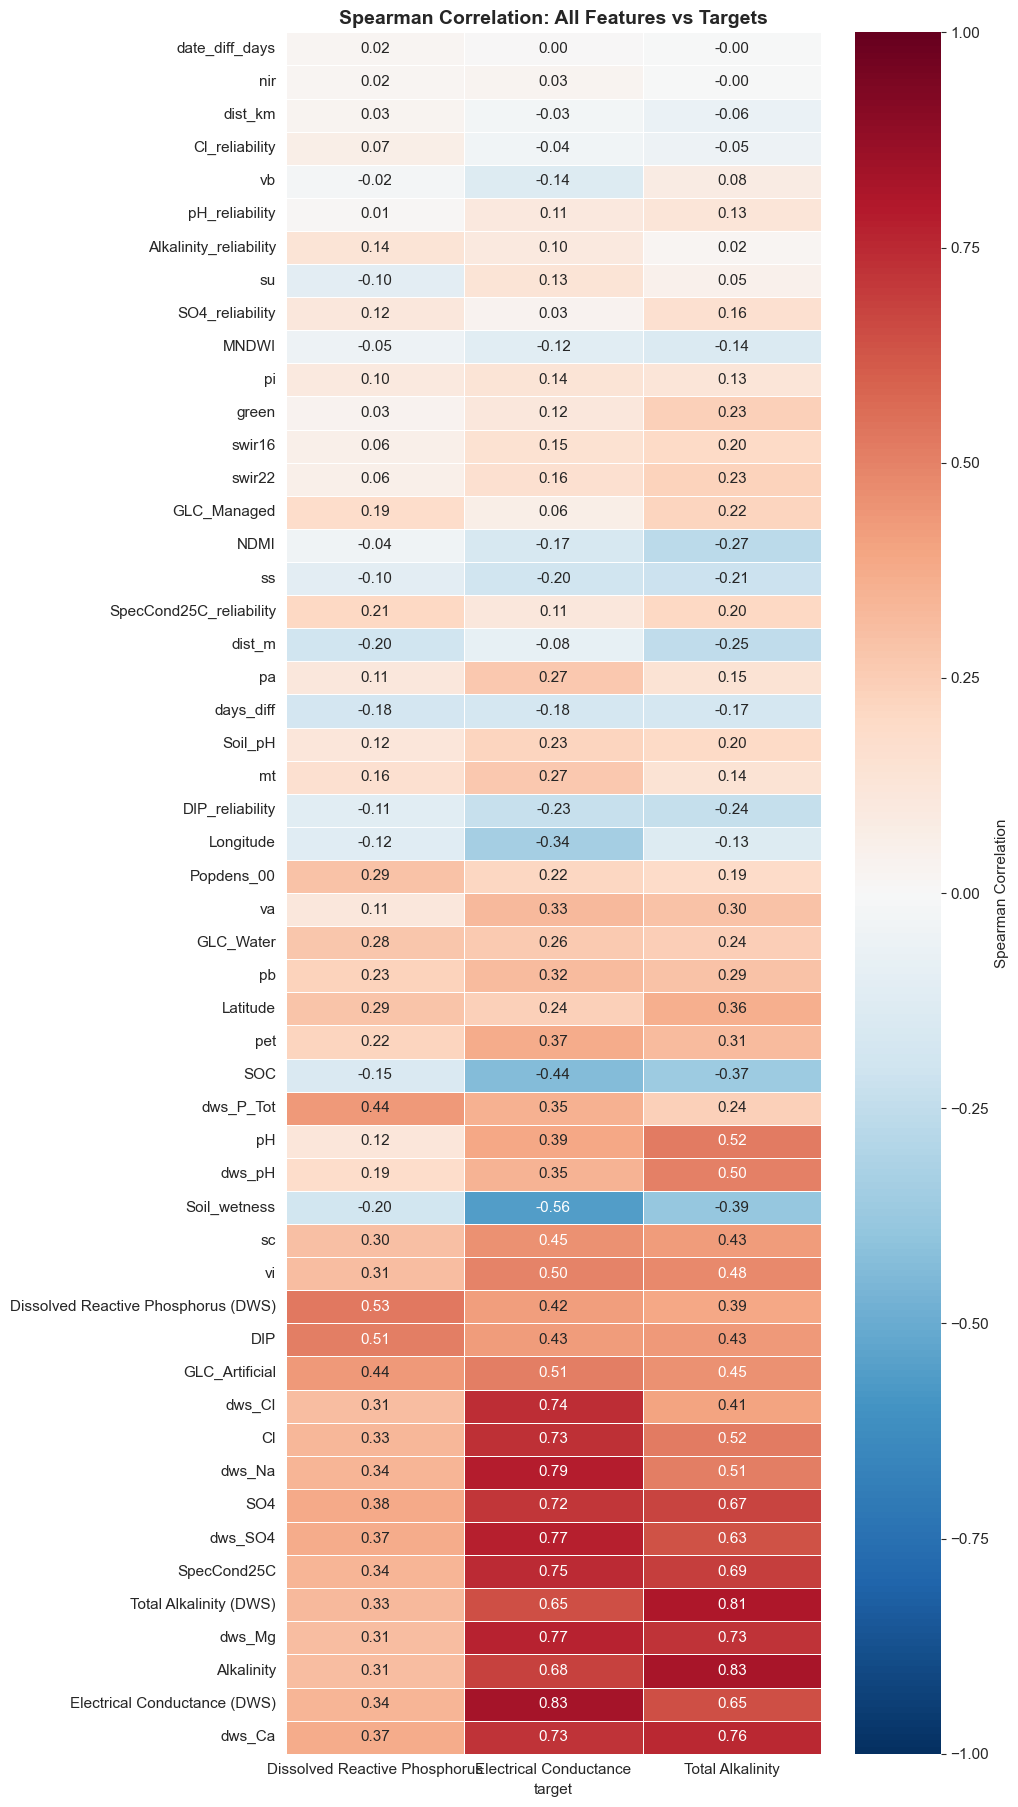

In [6]:
# Heatmap: Spearman correlation of ALL features vs 3 targets
pivot = corr_df.pivot_table(index='feature', columns='target', values='spearman')

# Sort by mean absolute correlation across all 3 targets
pivot['mean_abs'] = pivot.abs().mean(axis=1)
pivot = pivot.sort_values('mean_abs', ascending=True)
pivot = pivot.drop(columns='mean_abs')

fig, ax = plt.subplots(figsize=(10, max(12, len(pivot) * 0.35)))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Spearman Correlation'}
)
ax.set_title('Spearman Correlation: All Features vs Targets', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

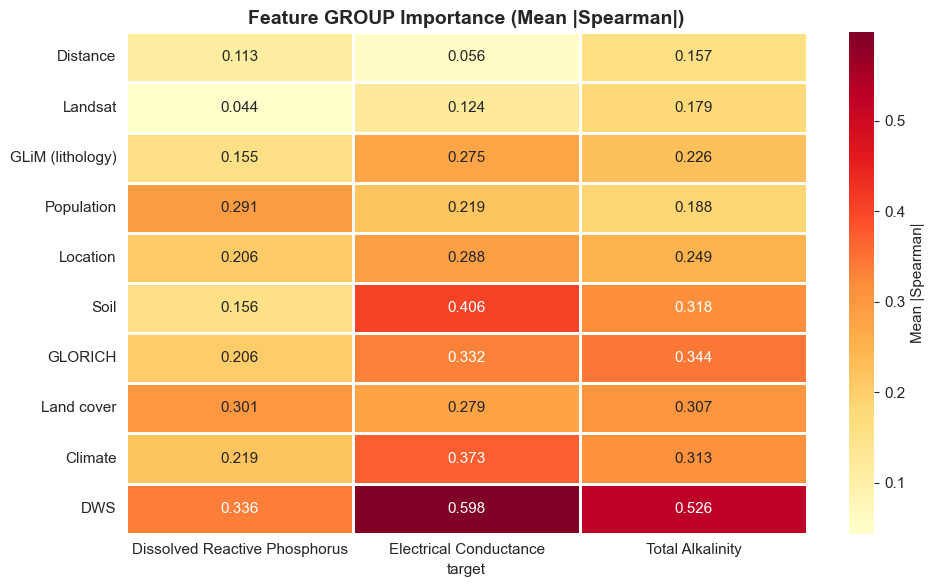

In [7]:
# Grouped heatmap: average |correlation| per feature GROUP per target
group_corr = corr_df.groupby(['group', 'target'])['abs_spearman'].mean().reset_index()
group_pivot = group_corr.pivot_table(index='group', columns='target', values='abs_spearman')
group_pivot['mean'] = group_pivot.mean(axis=1)
group_pivot = group_pivot.sort_values('mean', ascending=True)
group_pivot = group_pivot.drop(columns='mean')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    group_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=1, ax=ax,
    cbar_kws={'label': 'Mean |Spearman|'}
)
ax.set_title('Feature GROUP Importance (Mean |Spearman|)', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Random Forest Feature Importance

Fit a Random Forest per target using all features (with median imputation for missing values). Extract Gini importances + quick 5-fold CV R² to see if the model is learning anything.

In [8]:
# Prepare feature matrix (impute missing with median)
X_raw = df[feature_cols].copy()
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=feature_cols)

print(f'Feature matrix: {X.shape}')
print(f'Any remaining NaN: {X.isna().any().any()}')

Feature matrix: (9319, 54)
Any remaining NaN: False


In [9]:
# Fit RF per target and collect importances
rf_results = {}

for target in TARGETS:
    print(f'\n{"="*60}')
    print(f'Random Forest: {target}')
    print(f'{"="*60}')
    
    y = df[target].values
    
    # Fit
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    )
    
    # 5-fold CV score
    cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=-1)
    print(f'  5-fold CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
    print(f'  Per fold: {[f"{s:.4f}" for s in cv_scores]}')
    
    # Fit on full data for importances
    rf.fit(X, y)
    
    # Store importances
    imp = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf.feature_importances_,
        'group': [next((g for g, cols in FEATURE_GROUPS.items() if c in cols), 'Unknown') for c in feature_cols]
    }).sort_values('importance', ascending=False)
    
    rf_results[target] = imp
    
    # Print top 15
    print(f'\n  Top 15 features:')
    for i, (_, row) in enumerate(imp.head(15).iterrows()):
        bar = '█' * int(row['importance'] * 100)
        print(f"    {i+1:2d}. {row['feature']:45s} {row['importance']:.4f} {bar}  ({row['group']})")


Random Forest: Total Alkalinity
  5-fold CV R²: 0.7616 (+/- 0.0543)
  Per fold: ['0.7369', '0.8099', '0.7818', '0.8121', '0.6675']

  Top 15 features:
     1. Alkalinity                                    0.6556 █████████████████████████████████████████████████████████████████  (GLORICH)
     2. SOC                                           0.0497 ████  (Soil)
     3. dist_m                                        0.0355 ███  (Distance)
     4. NDMI                                          0.0331 ███  (Landsat)
     5. pet                                           0.0235 ██  (Climate)
     6. Soil_pH                                       0.0220 ██  (Soil)
     7. MNDWI                                         0.0192 █  (Landsat)
     8. green                                         0.0151 █  (Landsat)
     9. nir                                           0.0141 █  (Landsat)
    10. DIP                                           0.0130 █  (GLORICH)
    11. swir22                          

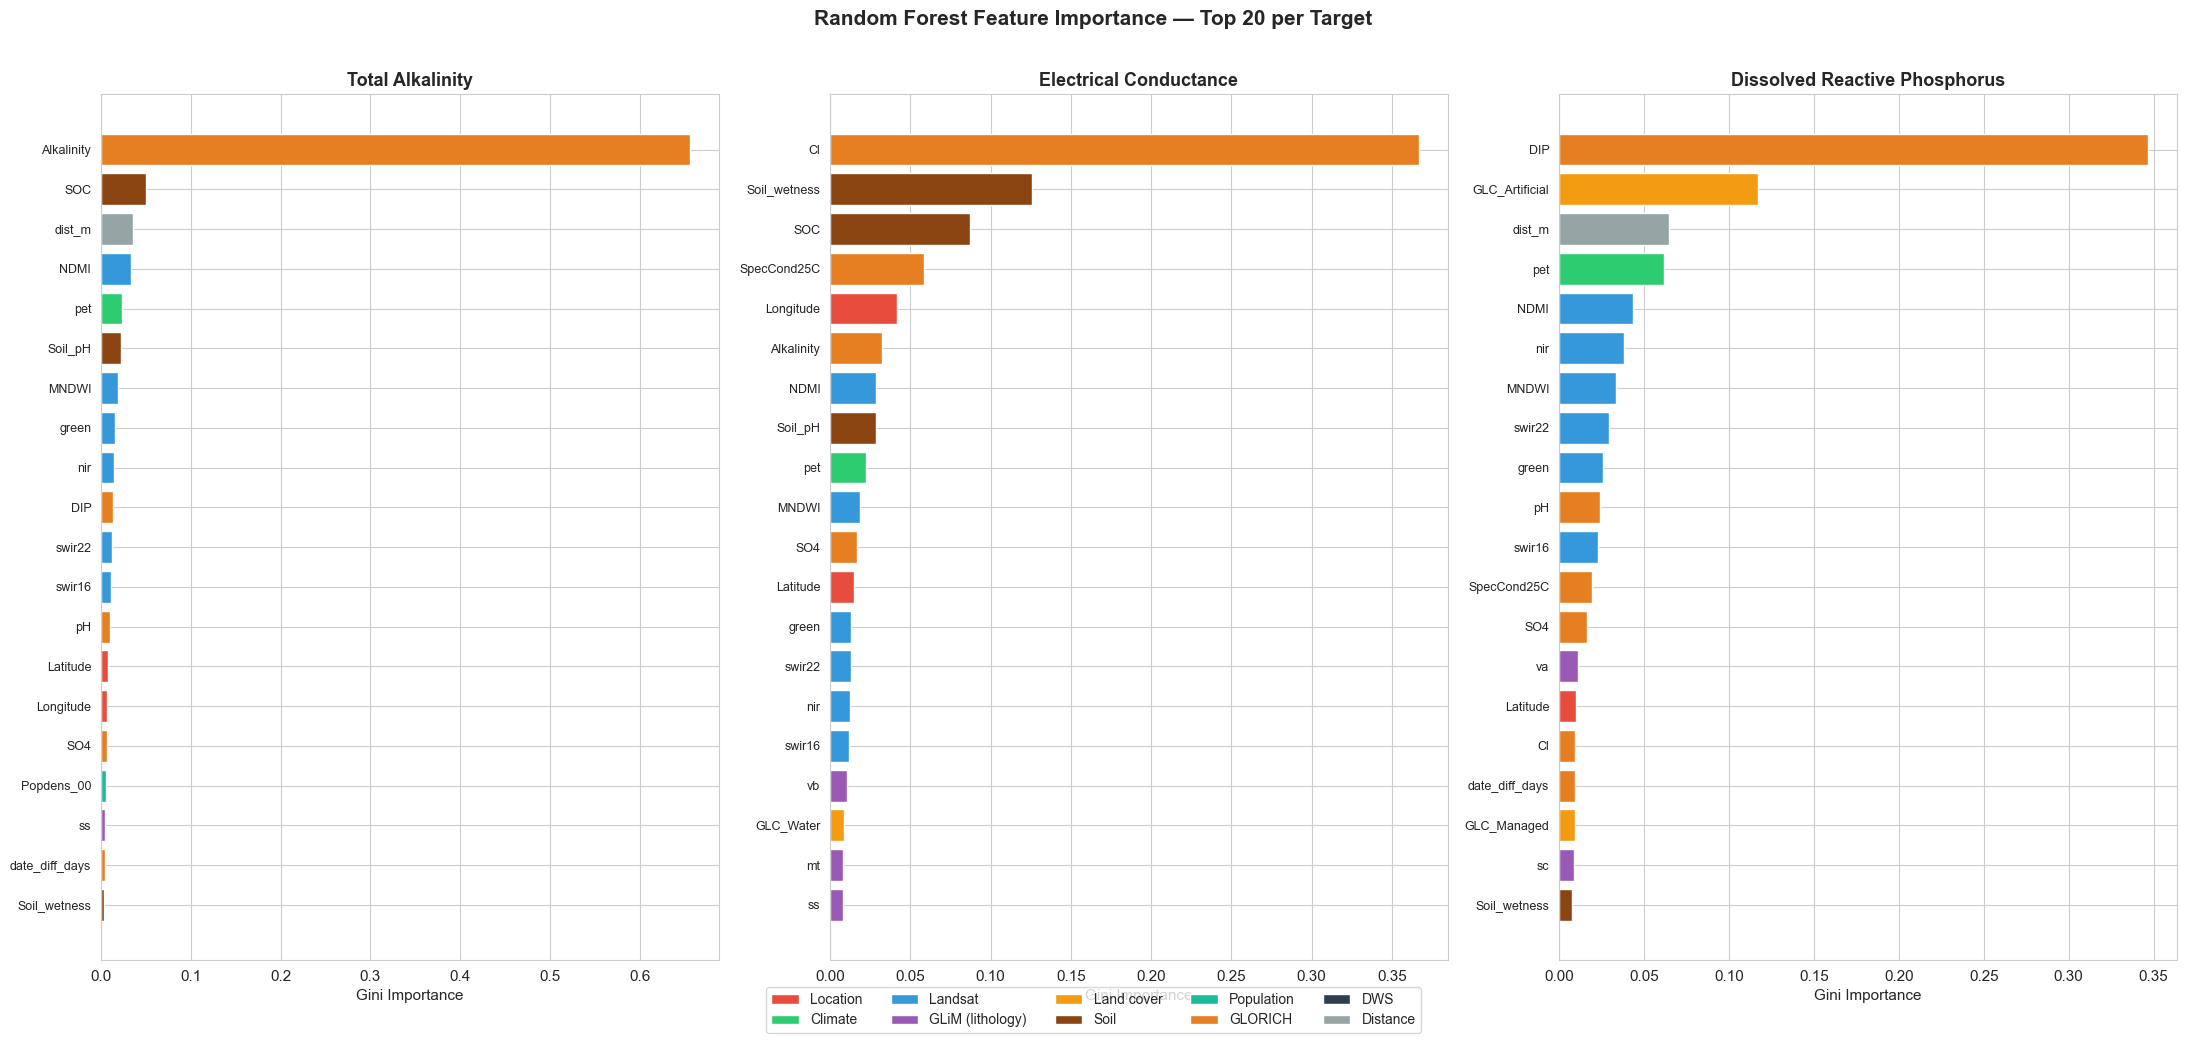

In [10]:
# Plot: top 20 features per target (side by side)
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# Color map for groups
group_colors = {
    'Location': '#e74c3c',
    'Climate': '#2ecc71',
    'Landsat': '#3498db',
    'GLiM (lithology)': '#9b59b6',
    'Land cover': '#f39c12',
    'Soil': '#8B4513',
    'Population': '#1abc9c',
    'GLORICH': '#e67e22',
    'DWS': '#2c3e50',
    'Distance': '#95a5a6',
    'Other': '#bdc3c7',
}

for ax, target in zip(axes, TARGETS):
    imp = rf_results[target].head(20).iloc[::-1]  # reverse for horizontal bar
    colors = [group_colors.get(g, '#bdc3c7') for g in imp['group']]
    
    ax.barh(imp['feature'], imp['importance'], color=colors)
    ax.set_xlabel('Gini Importance')
    ax.set_title(target, fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in group_colors.items() if g in set(corr_df['group'])]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Random Forest Feature Importance — Top 20 per Target', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

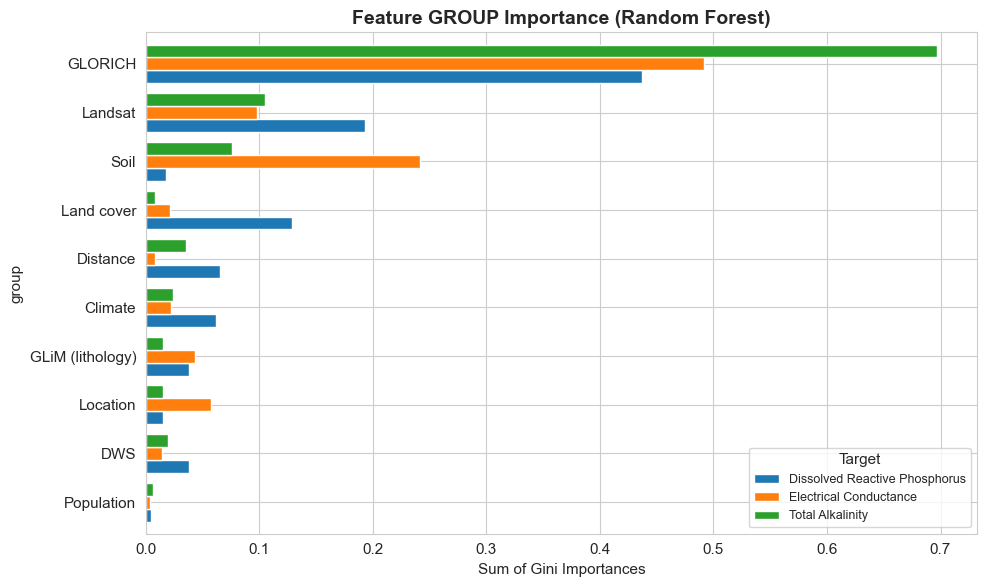


Group importance table:
target            Dissolved Reactive Phosphorus  Electrical Conductance  Total Alkalinity    mean
group                                                                                            
Population                               0.0048                  0.0036            0.0060  0.0048
DWS                                      0.0383                  0.0145            0.0193  0.0241
Location                                 0.0153                  0.0569            0.0147  0.0290
GLiM (lithology)                         0.0384                  0.0435            0.0152  0.0323
Climate                                  0.0619                  0.0221            0.0235  0.0358
Distance                                 0.0650                  0.0078            0.0355  0.0361
Land cover                               0.1288                  0.0211            0.0079  0.0526
Soil                                     0.0173                  0.2415            0.0755  0.

In [11]:
# Group-level RF importance: sum importances per feature group
group_imp_list = []
for target in TARGETS:
    imp = rf_results[target]
    gi = imp.groupby('group')['importance'].sum().reset_index()
    gi['target'] = target
    group_imp_list.append(gi)

group_imp = pd.concat(group_imp_list)
group_imp_pivot = group_imp.pivot_table(index='group', columns='target', values='importance')
group_imp_pivot['mean'] = group_imp_pivot.mean(axis=1)
group_imp_pivot = group_imp_pivot.sort_values('mean', ascending=True)
group_imp_pivot_plot = group_imp_pivot.drop(columns='mean')

fig, ax = plt.subplots(figsize=(10, 6))
group_imp_pivot_plot.plot(kind='barh', ax=ax, width=0.8)
ax.set_xlabel('Sum of Gini Importances')
ax.set_title('Feature GROUP Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.legend(title='Target', fontsize=9)
plt.tight_layout()
plt.show()

print('\nGroup importance table:')
print(group_imp_pivot.round(4).to_string())

In [18]:
# ============================================================
# RF Feature Importance: WITHOUT GLORICH (DWS columns get a fair shot)
# ============================================================
# This tests whether DWS importance is low because GLORICH is "stealing" it

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Identify GLORICH columns to drop
glorich_cols = [c for c in X.columns if c in [
    'Alkalinity', 'Cl', 'DIP', 'SpecCond25C', 'SO4', 'pH',
    # Add any other GLORICH column names present in your data
] or '(GLORICH)' in str(c)]

# If you tagged sources differently, adjust this:
# glorich_cols = [c for c in X.columns if 'glorich' in c.lower()]

print(f'GLORICH columns being dropped ({len(glorich_cols)}): {glorich_cols}')
X_no_glorich = X.drop(columns=glorich_cols, errors='ignore')
print(f'Remaining features: {X_no_glorich.shape[1]}')

# Fit RF per target and collect importances
rf_results = {}

for target in TARGETS:
    print(f'\n{"="*60}')
    print(f'Random Forest: {target}')
    print(f'{"="*60}')
    
    y = df[target].values
    
    # Fit
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    )
    
    # 5-fold CV score
    cv_scores = cross_val_score(rf, X_no_glorich, y, cv=5, scoring='r2', n_jobs=-1)
    print(f'  5-fold CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
    print(f'  Per fold: {[f"{s:.4f}" for s in cv_scores]}')
    
    # Fit on full data for importances
    rf.fit(X_no_glorich, y)
    
    # Store importances
    feature_cols_no_glorich = X_no_glorich.columns.tolist()
    imp = pd.DataFrame({
        'feature': feature_cols_no_glorich,
        'importance': rf.feature_importances_,
        'group': [next((g for g, cols in FEATURE_GROUPS.items() if c in cols), 'Unknown') for c in feature_cols_no_glorich]
    }).sort_values('importance', ascending=False)
    
    rf_results[target] = imp
    
    # Print top 15
    print(f'\n  Top 15 features:')
    for i, (_, row) in enumerate(imp.head(15).iterrows()):
        bar = '█' * int(row['importance'] * 100)
        print(f"    {i+1:2d}. {row['feature']:45s} {row['importance']:.4f} {bar}  ({row['group']})")

GLORICH columns being dropped (6): ['Alkalinity', 'Cl', 'DIP', 'SO4', 'SpecCond25C', 'pH']
Remaining features: 48

Random Forest: Total Alkalinity
  5-fold CV R²: 0.7294 (+/- 0.1080)
  Per fold: ['0.7366', '0.8046', '0.7881', '0.7987', '0.5188']

  Top 15 features:
     1. vi                                            0.1814 ██████████████████  (GLiM (lithology))
     2. Soil_wetness                                  0.1397 █████████████  (Soil)
     3. vb                                            0.1221 ████████████  (GLiM (lithology))
     4. Soil_pH                                       0.0610 ██████  (Soil)
     5. SOC                                           0.0456 ████  (Soil)
     6. dist_m                                        0.0422 ████  (Distance)
     7. Latitude                                      0.0421 ████  (Location)
     8. NDMI                                          0.0378 ███  (Landsat)
     9. sc                                            0.0283 ██  (GLiM (lit

In [19]:
X.columns

Index(['Latitude', 'Longitude', 'pet', 'nir', 'green', 'swir16', 'swir22',
       'NDMI', 'MNDWI', 'sc', 'ss', 'su', 'mt', 'va', 'vb', 'vi', 'pa', 'pb',
       'pi', 'GLC_Artificial', 'GLC_Managed', 'GLC_Water', 'GLC_Aquatic_Veg',
       'GLC_PERC_COV', 'Popdens_00', 'Soil_pH', 'SOC', 'Soil_wetness',
       'dist_m', 'dist_km', 'Alkalinity', 'Cl', 'DIP', 'SO4', 'SpecCond25C',
       'pH', 'Alkalinity_reliability', 'Cl_reliability', 'DIP_reliability',
       'SO4_reliability', 'SpecCond25C_reliability', 'pH_reliability',
       'date_diff_days', 'days_diff', 'Total Alkalinity (DWS)',
       'Electrical Conductance (DWS)', 'Dissolved Reactive Phosphorus (DWS)',
       'dws_pH', 'dws_Ca', 'dws_Mg', 'dws_Na', 'dws_Cl', 'dws_SO4',
       'dws_P_Tot'],
      dtype='object')

## 4. Summary Table: Combined View

For each feature, show the Spearman correlation AND Random Forest importance for each target, side by side.

In [12]:
# Build summary table
summary_rows = []

for feat in feature_cols:
    row = {'feature': feat}
    row['group'] = next((g for g, cols in FEATURE_GROUPS.items() if feat in cols), 'Unknown')
    row['coverage'] = f"{df[feat].notna().mean()*100:.0f}%"
    
    for target in TARGETS:
        short = target.split()[0][:3]  # 'Tot', 'Ele', 'Dis'
        
        # Spearman
        corr_row = corr_df[(corr_df['feature'] == feat) & (corr_df['target'] == target)]
        if len(corr_row) > 0:
            row[f'{short}_spearman'] = corr_row.iloc[0]['spearman']
        else:
            row[f'{short}_spearman'] = np.nan
        
        # RF importance
        rf_row = rf_results[target][rf_results[target]['feature'] == feat]
        if len(rf_row) > 0:
            row[f'{short}_rf_imp'] = rf_row.iloc[0]['importance']
        else:
            row[f'{short}_rf_imp'] = np.nan
    
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)

# Compute overall score (mean of absolute spearman + mean RF importance across 3 targets)
spearman_cols = [c for c in summary.columns if 'spearman' in c]
rf_cols = [c for c in summary.columns if 'rf_imp' in c]

summary['avg_abs_spearman'] = summary[spearman_cols].abs().mean(axis=1)
summary['avg_rf_imp'] = summary[rf_cols].mean(axis=1)
summary['overall_score'] = summary['avg_abs_spearman'].rank(pct=True) + summary['avg_rf_imp'].rank(pct=True)
summary = summary.sort_values('overall_score', ascending=False)

print('TOP 25 FEATURES (combined correlation + RF importance):\n')
display_cols = ['feature', 'group', 'coverage',
                'Tot_spearman', 'Tot_rf_imp',
                'Ele_spearman', 'Ele_rf_imp',
                'Dis_spearman', 'Dis_rf_imp',
                'avg_abs_spearman', 'avg_rf_imp']
print(summary[display_cols].head(25).to_string(index=False, float_format='%.4f'))

TOP 25 FEATURES (combined correlation + RF importance):

                            feature            group coverage  Tot_spearman  Tot_rf_imp  Ele_spearman  Ele_rf_imp  Dis_spearman  Dis_rf_imp  avg_abs_spearman  avg_rf_imp
                         Alkalinity          GLORICH      83%        0.8250      0.6556        0.6802      0.0326        0.3108      0.0021            0.6053      0.2301
                                 Cl          GLORICH      83%        0.5193      0.0036        0.7291      0.3666        0.3287      0.0096            0.5257      0.1266
                        SpecCond25C          GLORICH      83%        0.6906      0.0024        0.7485      0.0589        0.3401      0.0192            0.5930      0.0268
                                DIP          GLORICH      83%        0.4329      0.0130        0.4288      0.0029        0.5092      0.3464            0.4570      0.1207
                     GLC_Artificial       Land cover     100%        0.4546      0.0025      

In [13]:
# Save full summary to CSV for reference
summary.to_csv('feature_importance_summary.csv', index=False)
print('Saved full summary to: feature_importance_summary.csv')

Saved full summary to: feature_importance_summary.csv


## 5. Key Takeaways

Run this cell after everything above to get an automated summary.

In [14]:
print('=' * 70)
print('KEY FINDINGS')
print('=' * 70)

for target in TARGETS:
    short = target.split()[0][:3]
    print(f'\n--- {target} ---')
    
    # Top 5 by Spearman
    top_corr = corr_df[corr_df['target'] == target].nlargest(5, 'abs_spearman')
    print(f'  Top 5 correlated: {", ".join(top_corr["feature"].values)}')
    
    # Top 5 by RF
    top_rf = rf_results[target].head(5)
    print(f'  Top 5 RF importance: {", ".join(top_rf["feature"].values)}')
    
    # Overlap
    both = set(top_corr['feature'].values) & set(top_rf['feature'].values)
    if both:
        print(f'  In BOTH top 5: {", ".join(both)}')

print(f'\n--- Feature Group Rankings (by mean RF importance) ---')
group_rank = group_imp_pivot.sort_values('mean', ascending=False)
for i, (grp, row) in enumerate(group_rank.iterrows()):
    print(f'  {i+1}. {grp:25s} mean_importance={row["mean"]:.4f}')

print(f'\n--- DWS columns with <40% coverage ---')
dws_feats = [c for c in feature_cols if c.startswith('dws_') or '(DWS)' in c]
for f in dws_feats:
    cov = df[f].notna().mean() * 100
    row = summary[summary['feature'] == f].iloc[0] if f in summary['feature'].values else None
    if row is not None:
        print(f'  {f:45s} coverage={cov:.0f}%  avg_rf_imp={row["avg_rf_imp"]:.4f}')

print(f'\n--- CV R² scores ---')
print('  (These tell you how well all features together predict each target)')
print('  Re-run cell 3 to see exact values above.')

KEY FINDINGS

--- Total Alkalinity ---
  Top 5 correlated: Alkalinity, Total Alkalinity (DWS), dws_Ca, dws_Mg, SpecCond25C
  Top 5 RF importance: Alkalinity, SOC, dist_m, NDMI, pet
  In BOTH top 5: Alkalinity

--- Electrical Conductance ---
  Top 5 correlated: Electrical Conductance (DWS), dws_Na, dws_SO4, dws_Mg, SpecCond25C
  Top 5 RF importance: Cl, Soil_wetness, SOC, SpecCond25C, Longitude
  In BOTH top 5: SpecCond25C

--- Dissolved Reactive Phosphorus ---
  Top 5 correlated: Dissolved Reactive Phosphorus (DWS), DIP, dws_P_Tot, GLC_Artificial, SO4
  Top 5 RF importance: DIP, GLC_Artificial, dist_m, pet, NDMI
  In BOTH top 5: GLC_Artificial, DIP

--- Feature Group Rankings (by mean RF importance) ---
  1. GLORICH                   mean_importance=0.5420
  2. Landsat                   mean_importance=0.1319
  3. Soil                      mean_importance=0.1114
  4. Land cover                mean_importance=0.0526
  5. Distance                  mean_importance=0.0361
  6. Climate     

In [23]:
test = pd.read_csv('data/dws_matched_all_columns.csv')
test.columns

Index(['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity',
       'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'pet',
       '_merge_terra', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI',
       '_merge_landsat', 'Impute_Method', 'geometry', 'STAT_ID', 'sc', 'ss',
       'su', 'mt', 'va', 'vb', 'vi', 'pa', 'pb', 'pi', 'GLC_Artificial',
       'GLC_Managed', 'GLC_Water', 'GLC_Aquatic_Veg', 'GLC_PERC_COV',
       'Popdens_00', 'Soil_pH', 'SOC', 'Soil_wetness', 'dist_m', 'dist_km',
       'Latitude_glorich', 'Longitude_glorich', 'date', 'Alkalinity', 'Cl',
       'DIP', 'SO4', 'SpecCond25C', 'pH', 'Alkalinity_reliability',
       'Cl_reliability', 'DIP_reliability', 'SO4_reliability',
       'SpecCond25C_reliability', 'pH_reliability', 'date_diff_days',
       'dws_station_id', 'dws_date', 'days_diff', 'Total Alkalinity (DWS)',
       'Electrical Conductance (DWS)', 'Dissolved Reactive Phosphorus (DWS)',
       'dws_pH', 'dws_Ca', 'dws_Mg', 'dws_Na', 'dws_Cl', 

In [21]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 69 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Latitude                             200 non-null    float64
 1   Longitude                            200 non-null    float64
 2   Sample Date                          104 non-null    object 
 3   Total Alkalinity                     0 non-null      float64
 4   Electrical Conductance               0 non-null      float64
 5   Dissolved Reactive Phosphorus        0 non-null      float64
 6   pet                                  200 non-null    float64
 7   _merge_terra                         200 non-null    object 
 8   nir                                  200 non-null    float64
 9   green                                200 non-null    float64
 10  swir16                               200 non-null    float64
 11  swir22                          

In [22]:
test.columns

Index(['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity',
       'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'pet',
       '_merge_terra', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI',
       '_merge_landsat', 'Impute_Method', 'geometry', 'STAT_ID', 'sc', 'ss',
       'su', 'mt', 'va', 'vb', 'vi', 'pa', 'pb', 'pi', 'GLC_Artificial',
       'GLC_Managed', 'GLC_Water', 'GLC_Aquatic_Veg', 'GLC_PERC_COV',
       'Popdens_00', 'Soil_pH', 'SOC', 'Soil_wetness', 'dist_m', 'dist_km',
       'Latitude_glorich', 'Longitude_glorich', 'date', 'Alkalinity', 'Cl',
       'DIP', 'SO4', 'SpecCond25C', 'pH', 'Alkalinity_reliability',
       'Cl_reliability', 'DIP_reliability', 'SO4_reliability',
       'SpecCond25C_reliability', 'pH_reliability', 'date_diff_days',
       'dws_station_id', 'dws_date', 'days_diff', 'Total Alkalinity (DWS)',
       'Electrical Conductance (DWS)', 'Dissolved Reactive Phosphorus (DWS)',
       'dws_pH', 'dws_Ca', 'dws_Mg', 'dws_Na', 'dws_Cl', 